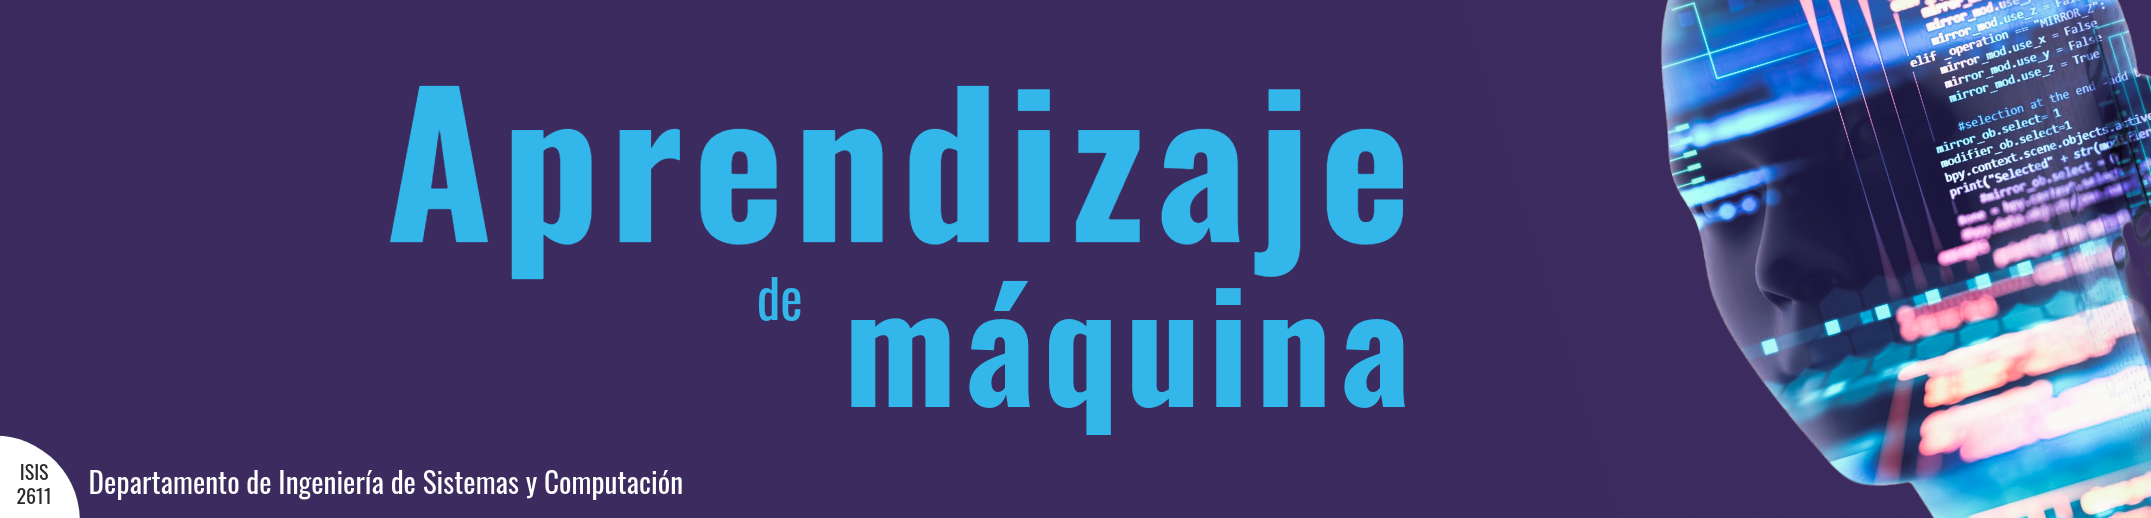

# Agrupación

En la práctica de hoy pasaremos del **Aprendizaje Supervisado** al **Aprendizaje No Supervisado**. A diferencia del paradígma supervisado, este no cuenta con un conjunto de etiquetas $Y$, por lo que su objetivo pasa de aproximar una función función $f: X \rightarrow Y$ a la identificación de la distribución subyacente de los datos ($\mathbb{P}(X)$), aspecto que comparten con los clasificadores generativos. Para descubrir patrones intrínsecos, estos métodos emplean medidas de similitud como la distancia euclidiana, la densidad, la correlación entre variables, entre otros.

Para abordar este tema, se utilizará el [Credit Card - Customer Segmentation Dataset](https://www.kaggle.com/code/elasgustavoknaus/customer-segmentation-clustering-credit-card). Este conjunto de datos contiene el comportamiento de aproximadamente $9,000$ propietarios de tarjetas de crédito durante seis meses. A través de $18$ variables, el objetivo es aplicar algoritmos de agrupamiento para segmentar a los usuarios y diseñar estrategias de marketing personalizadas.

El algoritmo seleccionado para resolver esta tarea es **K-Means**, el cual es un método de agrupación basado en centroides o prototipos (yambién conocido por particiones) que asigna cada elemento del conjunto de datos $X$ a uno de $K$ clústeres. Esta asignación se realiza mediante una métrica de similitud basada en la distancia: cada elemento $x_i$ se asocia al clúster cuyo centroide sea el más cercano. 

Se seguirá un flujo de Exploración de datos, seguido por la Construcción y posterior Evaluación de los modelos, para finalizar con un análisis de los resultados obtenidos.

Para ello el notebook se divide en:
1. Importación de librerías.
2. Exploración de datos.
3. Limpieza de datos.  
4. Construcción y Evaluación de modelos.
5. Análisis de resultados de agrupación.
6. Ejercicios.

## 1. Importación de librerías

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

## 2. Exploración de datos

Se carga el conjunto de datos y se visualiza su estructura:

In [65]:
customer = pd.read_csv('Customer_Data.csv', sep=',')

In [66]:
data = customer.copy()
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,5323.148883,0.250693,26344.072201,38237.442525,3727.113162,15708.239684,0.496536,0.464442,0.821611,0.194502,100,77,16819.480037,21337.027458,39452.958121,0.817907,7
1,C10002,12726.638115,0.791307,37958.519019,5690.742440,18733.810964,38284.354433,0.699457,0.250327,0.654863,1.083902,78,156,15617.570575,8000.183624,63013.748477,0.343119,9
2,C10003,4305.572068,0.176531,28392.953338,36009.470088,2873.383232,14294.185035,0.419764,0.523662,0.899912,0.207049,72,81,15515.586213,27111.360493,NaN,0.829074,6
3,C10004,4740.988511,0.178076,27399.003842,38246.863491,3402.853375,6936.812518,0.439666,0.606597,0.783129,0.228299,78,83,12926.587974,23919.113404,38444.219979,0.883984,7
4,C10005,13820.920640,0.826914,42214.021633,7341.007821,19273.070991,40091.347849,0.821412,0.283579,0.501361,1.106350,88,182,14404.705067,6994.688474,62041.617340,0.383186,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C18946,6095.221156,0.234346,27094.007822,35917.204378,3463.821376,11711.578889,0.469832,0.539477,0.828321,0.191030,75,101,17623.810282,23954.396952,34841.829885,0.866856,7
8946,C18947,12682.575822,0.686025,38433.618847,5293.541956,18924.799798,34444.867317,0.710331,0.276426,0.546059,0.935152,95,170,12433.814929,7375.625322,66726.372993,0.306600,10
8947,C18948,16464.311409,0.189136,4296.196384,32554.759639,11231.500433,15214.671563,0.424665,0.746010,0.690380,1.063788,51,151,3307.587117,22947.759217,54761.962206,0.129242,8
8948,C18949,15531.883777,0.117118,12219.325647,31795.971700,12390.432127,13856.393208,0.450670,0.805140,0.608737,1.058548,61,178,6148.232910,21369.503519,50368.309060,0.087448,8


Se observa que el dataset está compuesto por $8950$ entradas donde cada una cuenta con 18 variables que la describen. El diccionario de datos asociado a estas variables es:


| Variable | Tipo | Descripción | Unidad / Escala |
| :--- | :--- | :--- | :--- |
| **CUST_ID** | Categórica| Identificación del titular de la tarjeta de crédito | ID Único |
| **BALANCE** | Numérica | Saldo restante en la cuenta para realizar compras | Moneda |
| **BALANCE_FREQUENCY** | Numérica | Frecuencia de actualización del saldo | Escala 0 a 1 |
| **PURCHASES** | Numérica | Monto total gastado en compras desde la cuenta | Moneda |
| **ONEOFF_PURCHASES** | Numérica | Monto máximo de compra realizado en una sola transacción | Moneda |
| **INSTALLMENTS_PURCHASES** | Numérica | Monto total gastado en compras a plazos (cuotas) | Moneda |
| **CASH_ADVANCE** | Numérica | Monto de adelantos en efectivo retirados por el usuario | Moneda |
| **PURCHASES_FREQUENCY** | Numérica | Frecuencia con la que se realizan compras | Escala 0 a 1 |
| **ONEOFFPURCHASESFREQUENCY** | Numérica | Frecuencia de compras en una sola exhibición | Escala 0 a 1 |
| **PURCHASESINSTALLMENTSFREQUENCY** | Numérica | Frecuencia de compras a plazos | Escala 0 a 1 |
| **CASHADVANCEFREQUENCY** | Numérica | Frecuencia con la que se retiran adelantos en efectivo | Escala 0 a 1 |
| **CASHADVANCETRX** | Numérica | Número de transacciones realizadas con adelantos en efectivo | Cantidad (Entero) |
| **PURCHASES_TRX** | Numérica | Número de transacciones de compra realizadas | Cantidad (Entero) |
| **CREDIT_LIMIT** | Numérica | Límite de crédito disponible para el usuario | Moneda |
| **PAYMENTS** | Numérica | Monto total de pagos realizados por el usuario | Moneda |
| **MINIMUM_PAYMENTS** | Numérica | Monto mínimo pagado por el usuario | Moneda |
| **PRCFULLPAYMENT** | Numérica | Porcentaje del pago total realizado por el usuario | Porcentaje / Ratio |
| **TENURE** | Numérica | Antigüedad del usuario con el servicio de la tarjeta de crédito | Meses |

### Descripción de los datos

### Verificación de completitud

In [67]:
(data.isnull().sum()/len(data) * 100).rename('Null %')

CUST_ID                             0.000000
BALANCE                             0.000000
BALANCE_FREQUENCY                   0.000000
PURCHASES                           0.000000
ONEOFF_PURCHASES                    0.000000
INSTALLMENTS_PURCHASES              0.000000
CASH_ADVANCE                        0.000000
PURCHASES_FREQUENCY                 0.000000
ONEOFF_PURCHASES_FREQUENCY          0.000000
PURCHASES_INSTALLMENTS_FREQUENCY    0.000000
CASH_ADVANCE_FREQUENCY              0.000000
CASH_ADVANCE_TRX                    0.000000
PURCHASES_TRX                       0.000000
CREDIT_LIMIT                        0.011173
PAYMENTS                            0.000000
MINIMUM_PAYMENTS                    3.497207
PRC_FULL_PAYMENT                    0.000000
TENURE                              0.000000
Name: Null %, dtype: float64

Se observa que las variables `CREDIT_LIMIT`y `MINIMUM_PAYMENTS` contienen un porcentage pequeño de valores nulos, por lo que se pueden eliminar estos registros.

### Verificación de Unicidad

In [68]:
duplicate_percentage = data.duplicated().sum()/len(data) * 100
duplicate_percentage2 = data["CUST_ID"].duplicated().sum()/len(data) * 100

print(f'Porcentaje de datos completamente duplicados: {duplicate_percentage:.3f}%')
print(f'Porcentaje de datos con CUST_ID duplicados: {duplicate_percentage2:.3f}%')

Porcentaje de datos completamente duplicados: 0.000%
Porcentaje de datos con CUST_ID duplicados: 0.000%


No se presentan duplicados.

### Verificación de Consistencia y Validez

In [69]:
data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,9382.387900,0.459205,30525.873439,22913.665720,11407.851805,22573.474202,0.559810,0.478032,0.623916,0.734946,76.169162,164.981453,14696.640361,19824.347218,44222.977795,0.545414,8.370615
std,5118.113559,0.282998,11041.410943,13573.919086,7087.102996,12594.295895,0.214055,0.221873,0.208207,0.422563,22.260935,71.322003,5537.074673,11069.268177,15468.314241,0.267443,1.756035
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,1006.064965,0.000000,6.000000
25%,4275.036859,0.188490,27106.651600,6698.252490,3736.720194,10944.431111,0.407273,0.250856,0.518231,0.230716,65.000000,97.000000,13487.727313,9329.603116,31572.127683,0.336732,7.000000
50%,12007.718812,0.306650,30934.582274,31011.033488,10832.141085,19465.792260,0.505305,0.533521,0.607608,0.947651,82.000000,176.000000,14942.545347,21367.621276,48780.271754,0.432690,8.000000
75%,13740.565876,0.756061,39825.160798,34495.416423,19127.083036,36150.722564,0.777084,0.649120,0.814929,1.029172,92.000000,216.000000,16269.727124,25219.127375,57761.175985,0.815178,10.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


Aunque los rangos de las variables numéricas muestran una varianza considerable, no son lo suficientemente distantes como para afirmar que hay un problema de consistencia de los datos. Sin embargo, se detectó un problema de validez en la variable `CASH_ADVANCE_FREQUENCY`, la cual presenta valores superiores a 1. Por lo tanto, se debe corregir esta anomalía durante la de limpieza de datos.

## 3. Limpieza de datos

### Eliminación de variables poco relevantes

Lo primero que haremos es eliminar la variable `CUST_ID`, que no aporta información relevante para nuestro problema:

In [70]:
data.drop('CUST_ID', axis=1, inplace=True)

### Datos nulos
La exploración de datos reveló que las variables `CREDIT_LIMIT` y `MINIMUM_PAYMENTS`contienen una pequeña cantidad de registros nulos. Dado que son pocos, se decide eliminar estos registros. Otra opción podría ser imputar por la mediana, que es un método robusto en caso de que se detecten outliers. 

In [71]:
print("Valores nulos antes de imputar:")
print(data.isnull().sum()[data.isnull().sum() > 0])

data = data.dropna(how="any")

print("\nValores nulos después de imputar:")
(data.isnull().sum()/len(data) * 100).rename('Null %')

Valores nulos antes de imputar:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Valores nulos después de imputar:


BALANCE                             0.0
BALANCE_FREQUENCY                   0.0
PURCHASES                           0.0
ONEOFF_PURCHASES                    0.0
INSTALLMENTS_PURCHASES              0.0
CASH_ADVANCE                        0.0
PURCHASES_FREQUENCY                 0.0
ONEOFF_PURCHASES_FREQUENCY          0.0
PURCHASES_INSTALLMENTS_FREQUENCY    0.0
CASH_ADVANCE_FREQUENCY              0.0
CASH_ADVANCE_TRX                    0.0
PURCHASES_TRX                       0.0
CREDIT_LIMIT                        0.0
PAYMENTS                            0.0
MINIMUM_PAYMENTS                    0.0
PRC_FULL_PAYMENT                    0.0
TENURE                              0.0
Name: Null %, dtype: float64

In [72]:
data = data.dropna(how="any")

### Datos con problemas de validez
Con el fin de caracterizar el problema de validez identificado para la variable `CASH_ADVANCE_FREQUENCY` grafica el histograma de esta variable.

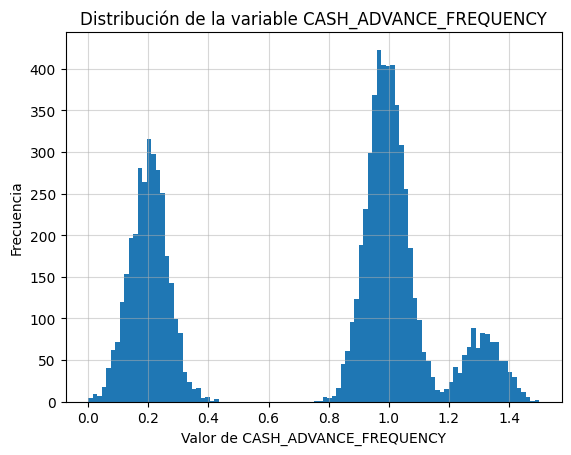

In [73]:
counts, bin_edges = np.histogram(data['CASH_ADVANCE_FREQUENCY'], bins=100)

fig, ax = plt.subplots()
ax.stairs(counts, bin_edges, fill=True)
ax.set(xlabel='Valor de CASH_ADVANCE_FREQUENCY', ylabel='Frecuencia', title='Distribución de la variable CASH_ADVANCE_FREQUENCY')
ax.grid(alpha=0.5)
plt.show()

Se observa que una proporción significativa de los registros supera el valor de $1$, por lo que descartarlos no es una opción viable. Sin embargo, la distribución presenta un comportamiento bastante inusual: un vacío de datos entre los valores $0.4$ y $0.8$. Dado que el valor máximo es exactamente $1.5$, es razonable suponer que se sumó accidentalmente una constante de $0.5$ a una fracción de la muestra.

Para validar la viabilidad de este ajuste, se analizan las distribuciones de las variables `CASH_ADVANCE` y `CASH_ADVANCE_TR` con el fin de identificar posibles discontinuidades. Dado que ambas están altamente correlacionadas con `CASH_ADVANCE_FREQUENCY`, es de esperar que presenten distribuciones y comportamientos similares.

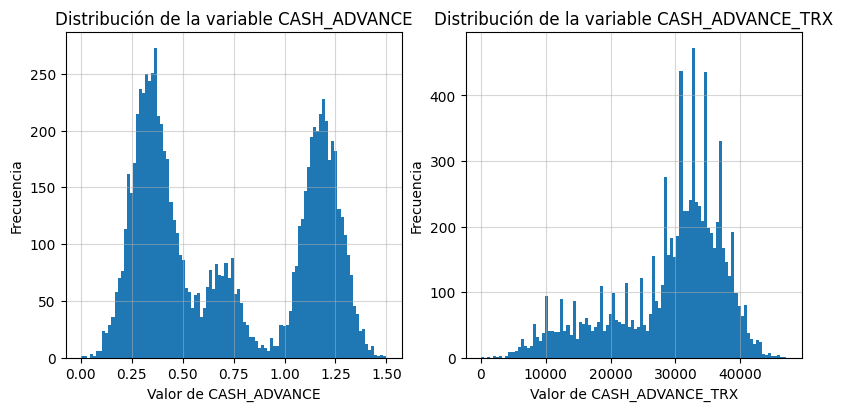

In [74]:
counts_cash_advance, bin_cash_advance = np.histogram(data['CASH_ADVANCE'], bins=100)
counts_cash_advance_TR, bin_cash_advance_TR = np.histogram(data['CASH_ADVANCE_TRX'], bins=100)

fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(8,4))
ax[0].stairs(counts_cash_advance, bin_edges, fill=True)
ax[0].set(xlabel='Valor de CASH_ADVANCE', ylabel='Frecuencia', title='Distribución de la variable CASH_ADVANCE')
ax[0].grid(alpha=0.5)

ax[1].stairs(counts_cash_advance_TR, bin_cash_advance, fill=True)
ax[1].set(xlabel='Valor de CASH_ADVANCE_TRX', ylabel='Frecuencia', title='Distribución de la variable CASH_ADVANCE_TRX')
ax[1].grid(alpha=0.5)
plt.show()

En ambos casos se observan distribuciones continuas con comportamiento trimodal, por lo que para para restaurar la distribución original de la variable `CASH_ADVANCE_FREQUENCY` y evitar sesgos en los algoritmos, se restará $0.5$ a todos los valores superiores a $0.6$ de esta variable.

In [75]:
data.loc[0.6 < data['CASH_ADVANCE_FREQUENCY'], 'CASH_ADVANCE_FREQUENCY'] -= 0.5

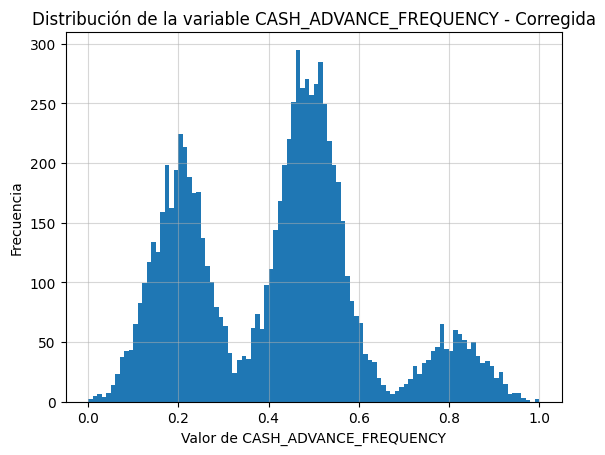

In [76]:
counts, bin_edges = np.histogram(data['CASH_ADVANCE_FREQUENCY'], bins=100)

fig, ax = plt.subplots()
ax.stairs(counts, bin_edges, fill=True)
ax.set(xlabel='Valor de CASH_ADVANCE_FREQUENCY', ylabel='Frecuencia', title='Distribución de la variable CASH_ADVANCE_FREQUENCY - Corregida')
ax.grid(alpha=0.5)
plt.show()

Se verifica que la correción fue existosa debido que se retoma el carácter continuo de la distribución y que el rango de valores está entre $0$ y $1$.

### Outliers

Para identificar y cuantificar la presencia de valores atípicos en las distintas variables, se utiliza el método del Rango Intercuartíl (IQR):

In [77]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
total = outliers.sum()
print(total)

BALANCE                                0
BALANCE_FREQUENCY                      0
PURCHASES                            733
ONEOFF_PURCHASES                       0
INSTALLMENTS_PURCHASES                 0
CASH_ADVANCE                           0
PURCHASES_FREQUENCY                    0
ONEOFF_PURCHASES_FREQUENCY             0
PURCHASES_INSTALLMENTS_FREQUENCY      18
CASH_ADVANCE_FREQUENCY                 3
CASH_ADVANCE_TRX                     239
PURCHASES_TRX                          0
CREDIT_LIMIT                        2108
PAYMENTS                               5
MINIMUM_PAYMENTS                       0
PRC_FULL_PAYMENT                       0
TENURE                                 0
dtype: int64


In [78]:
datos_outliers = outliers.any(axis=1).sum()
print(f"Número de datos con outliers: {datos_outliers}")

Número de datos con outliers: 2109


Debido a que un gran número del total de registros sería considerad como atípico, se prefiere conservar estos registros para no eliminar su información.

### Estandarización

Finalmente, realizaremos una estandarización de los datos, para así evitar que las magnitudes de las variables tengan influencia sobre los algoritmos. En este caso usaremos un `RobustScaler()` que es más robusto que `StandarScaler()` cuando se tienen valores extremos:

In [79]:
robust_scaler = RobustScaler()
scaled_data = robust_scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
scaled_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.706404,-0.096365,-0.360201,0.259907,-0.461199,-0.149359,-0.022136,-0.174313,0.721663,-0.850026,0.666667,-0.831933,0.674718,-0.001738,-0.356376,0.804098,-0.333333
1,0.075457,0.855976,0.554035,-0.911285,0.513621,0.746618,0.527013,-0.713970,0.159355,0.456239,-0.148148,-0.168067,0.242031,-0.841000,0.543236,-0.186756,0.333333
2,-0.767884,-0.224286,-0.277162,0.260246,-0.482262,-0.497470,-0.176037,0.183976,0.591893,-0.736652,-0.148148,-0.781513,-0.726723,0.160748,-0.394892,0.941998,-0.333333
3,0.191021,0.918701,0.889008,-0.851900,0.548651,0.818332,0.857051,-0.630162,-0.358285,0.531543,0.222222,0.050420,-0.194601,-0.904274,0.506117,-0.103139,0.666667
4,0.045087,0.706886,0.767803,-0.894535,0.556992,0.514631,0.898597,-0.478037,-0.269085,0.076473,0.777778,0.336134,-0.140526,-0.789773,0.360487,-0.071436,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,-0.624868,-0.125160,-0.301170,0.176413,-0.478302,-0.307974,-0.094401,0.014804,0.744291,-0.861671,-0.259259,-0.630252,0.964277,0.162969,-0.532440,0.906252,-0.333333
8632,0.070804,0.670512,0.591432,-0.925578,0.526027,0.594241,0.556441,-0.648191,-0.207554,-0.042751,0.481481,-0.050420,-0.904121,-0.880302,0.684994,-0.262969,0.666667
8633,0.470182,-0.204803,-2.095708,0.055416,0.026279,-0.168947,-0.216634,0.535351,0.279126,0.388766,-1.148148,-0.210084,-4.189564,0.099623,0.228162,-0.633106,0.000000
8634,0.371711,-0.331669,-1.472036,0.028111,0.101562,-0.222853,-0.146259,0.684382,0.003808,0.371187,-0.777778,0.016807,-3.166931,0.000306,0.060401,-0.720327,0.000000


## 4. Construcción y Evaluación de modelos.
Debido a que en el aprendizaje no supervizado no se cuenta con un conjunto de etiquetas que indiquen si un dato fue correctamente agrupado o no, la evaluación y selección de hiperparámetros de un modelo se realiza con base en heurísticas y métricas discriptivas de los clústers. En esta ocasión se trabajará con dos de ellas, el método del codo y el método de la silueta. Para ello se definen las funciones  `elbow_plot()` y `silhouette_plot()`, las cuales entrenarán el `K-Means` variando el parámetro $K$ para así encontrar el más adecuado para este conjunto de datos.


### El método del codo

Este método se basa en la métrica de inercia, que representa la suma de las distancias al cuadrado entre los elementos de cada clúster y su representante $(\mu_i)$. Se define como:
$$
Inercia = \sum_{i=1}^k \sum_{x \in C_i} || x - \mu_i^2 ||
$$

A medida que el número de clústeres aumenta, el valor de la inercia disminuye. Sin embargo, existe un punto en el que la reducción de la inercia deja de ser significativa. Este punto se conoce como 'el codo' e indica el número de clústeres más adecuado para el conjunto de datos.

In [80]:
def elbow_plot(X, k_min=2, k_max=10):
    """
    Genera la gráfica para el método del codo usando KMeans
    Parametros:
    X : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    """
    inertias = []
    for i in range(k_min, k_max+1):
        model_k = KMeans(n_clusters=i, max_iter=300, n_init=10, random_state=0)
        # Entrenamos el modelo
        model_k.fit(X)
        # Almacenamos el valor de inercia
        inertias.append(model_k.inertia_)

    # Graficamos los valores de inercia
    plt.plot(range(k_min,k_max+1), inertias, marker='o')
    plt.xlabel('Número de clústeres')
    plt.ylabel('Inercia')
    plt.grid()
    plt.show()

Se evaluan los modelos para $K \in [2, 15]$

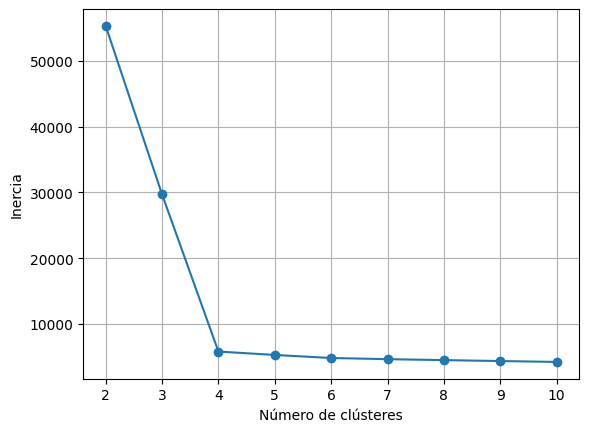

In [81]:
elbow_plot(scaled_df, 2, 10)

Para KMeans podemos observar una disminución considerable en la inercia desde `K=3`. Sin embargo, si tenemos en cuenta la definición del método del codo, el valor óptimo de `K` es **4**, ya que después de este es cuando se tiene un comportamiento aproximadamente lineal.

### Análisis de Silueta

A diferencia del método del codo, el coeficiente de silueta evalúa qué tan bien se adapta cada objeto a su clúster comparándolo con los clústeres vecinos. Para un dato $x_i$, su silueta $s(i)$ se define como:

$$
s(i) = \frac{b(i) - a(i)}{\max(b(i), a(i))}
$$

Donde $a(i)$ es la distancia promedio a los demás puntos del mismo clúster (cohesión) y $b(i)$ es la distancia promedio a los puntos del clúster más cercano (separación). El coeficiente oscila entre $-1$ y $1$. Un valor cercano a $1$ indica que el dato está muy bien agrupado, mientras que valores cercanos a $0$ o negativos sugieren solapamiento entre clústeres. El número óptimo $K$ será aquel que maximice el promedio de la silueta en todo el conjunto.

In [82]:
def silhouette_plot(X, k_min=2, k_max=5):
    """
    Genera la gráfica con el coeficiente de la silueta

    Parametros:
    X : np.array
        El arreglo con los datos
    model : str
        "kmeans" o "kmedoids", especifica el modelo a entrenar.
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    """
    scores = []
    for i in range(k_min, k_max+1):
        model_k = KMeans(n_clusters=i, max_iter=300, n_init=10, random_state=0)
        # Entrenamos el modelo
        model_k.fit(X)
        # Almacenamos el coeficiente de la silueta
        score = silhouette_score(X, model_k.labels_)
        scores.append(score)
    # Mostramos los valores de los coeficientes
    # Graficamos los valores del coeficiente de la silueta
    plt.plot(range(k_min,k_max+1), scores, marker='o')
    plt.xlabel('Número de clústeres')
    plt.ylabel('Silhouette Score')
    plt.grid()
    plt.show()

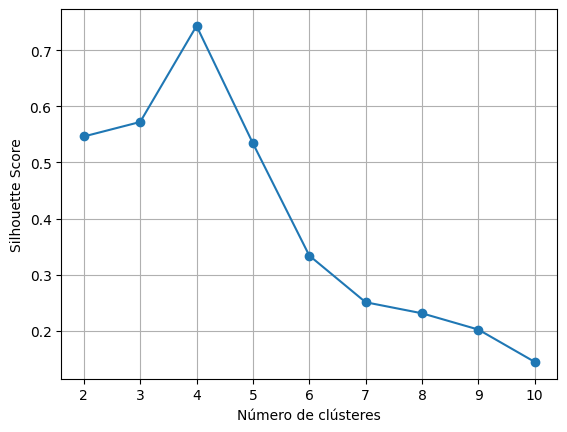

In [83]:
silhouette_plot(scaled_df, 2, 10)

Continuando con lo que observamos utilizando el método del codo, el valor más alto del coeficiente de la silueta se presenta en `K=4`. Para obtener una descripción más detallada del coeficiente de la silueta para cada escenario, definiremos la función silhouette_analysis():

In [84]:
def silhouette_analysis(X, k_min=2, k_max=8):
    """
    Genera gráficas con el coeficiente de la silueta para cada clúster y cada ejemplo

    Parametros:
    X : np.array
        El arreglo con los datos
    k_min : int
        Valor mínimo para k
    k_max : int
        Valor máximo para k
    """
    for n_clusters in range(k_min, k_max+1):
        clusterer = KMeans(n_clusters)

        # Entrenamos el modelo
        cluster_labels = clusterer.fit_predict(X)
        # Obtenemos el coeficiente promedio
        silhouette_avg = silhouette_score(X, cluster_labels)
        # Obtenemos el coeficiente para cada ejemplo
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        # Inicializamos una figura
        fig = plt.figure(figsize = (18, 7))
        plt.xlim([-0.2, 1])
        plt.ylim([0, len(X) + (n_clusters + 1) * 10])
        y_lower = 10
        for i in range(n_clusters):
            # Obtenemos los valores del coeficiente para cada cluster
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            # Ordenamos los valores de mayor a menor
            ith_cluster_silhouette_values.sort()
            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            plt.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        plt.title(f"Método de la silueta (k={n_clusters})")
        plt.xlabel("Coeficiente")
        plt.ylabel("Clúster")

        # Incluimos el valor promedio
        plt.axvline(x=silhouette_avg, color="red", linestyle="--")
        plt.yticks([])
        plt.xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()

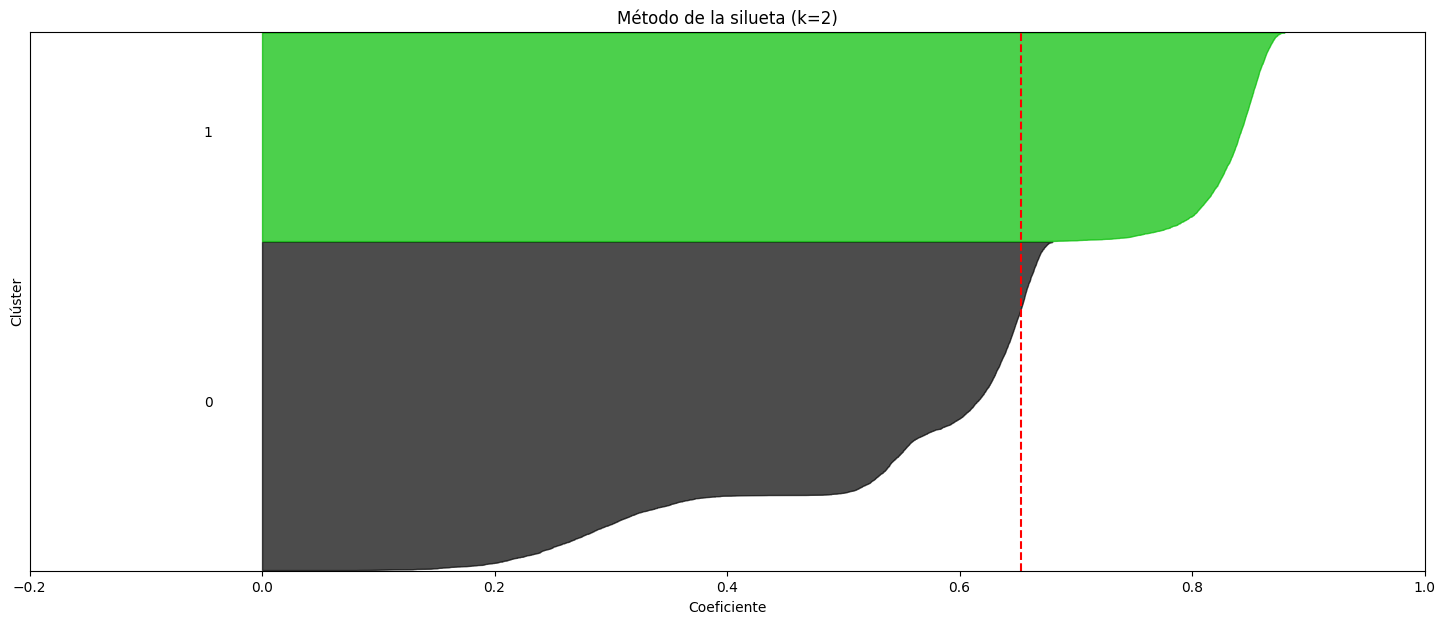

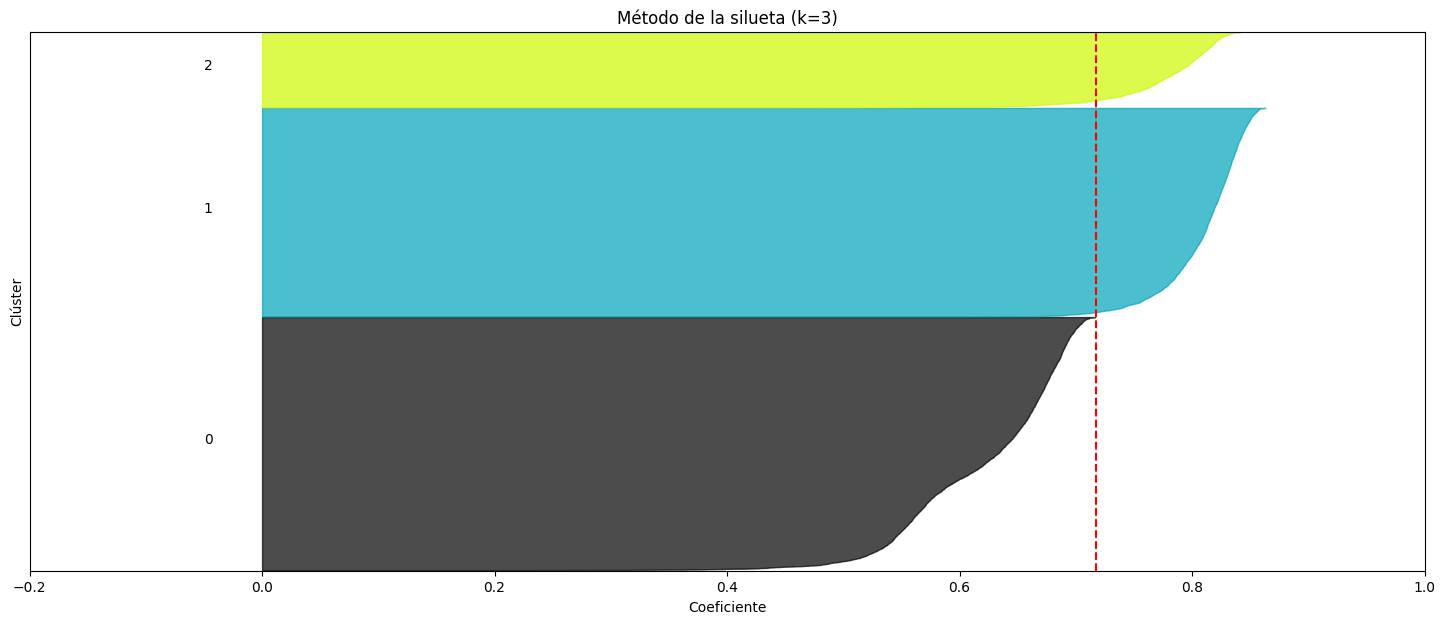

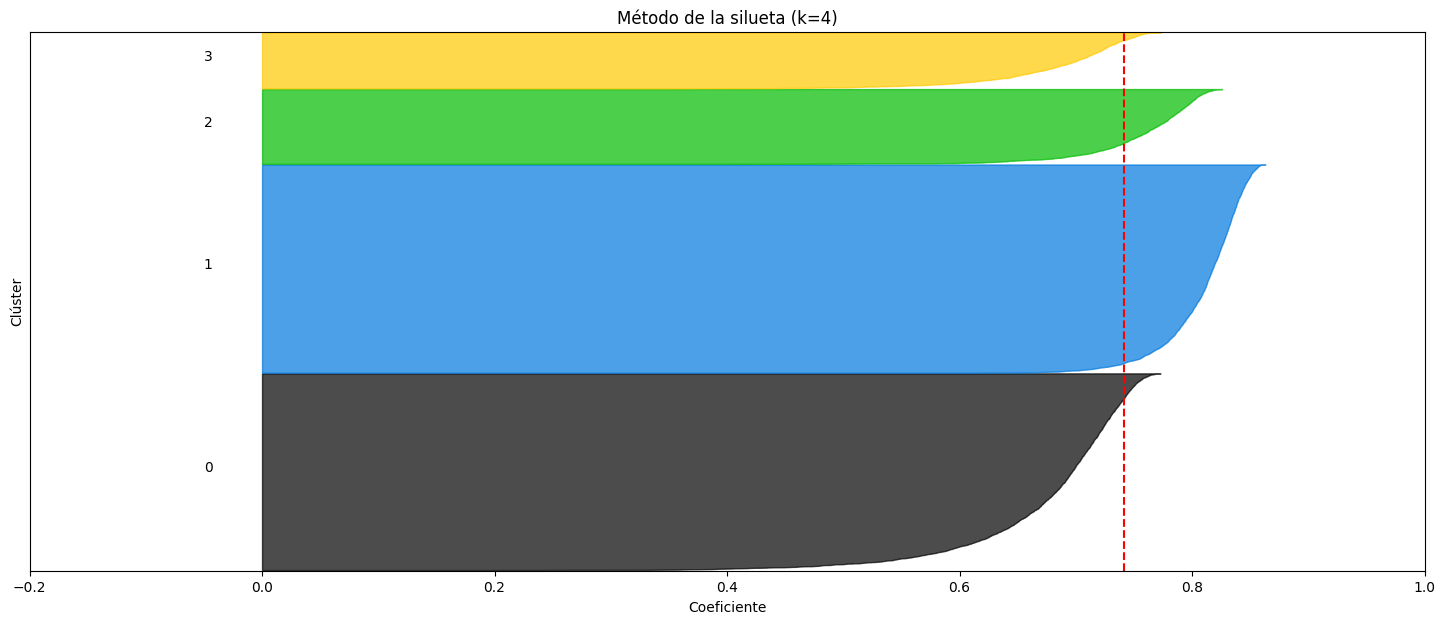

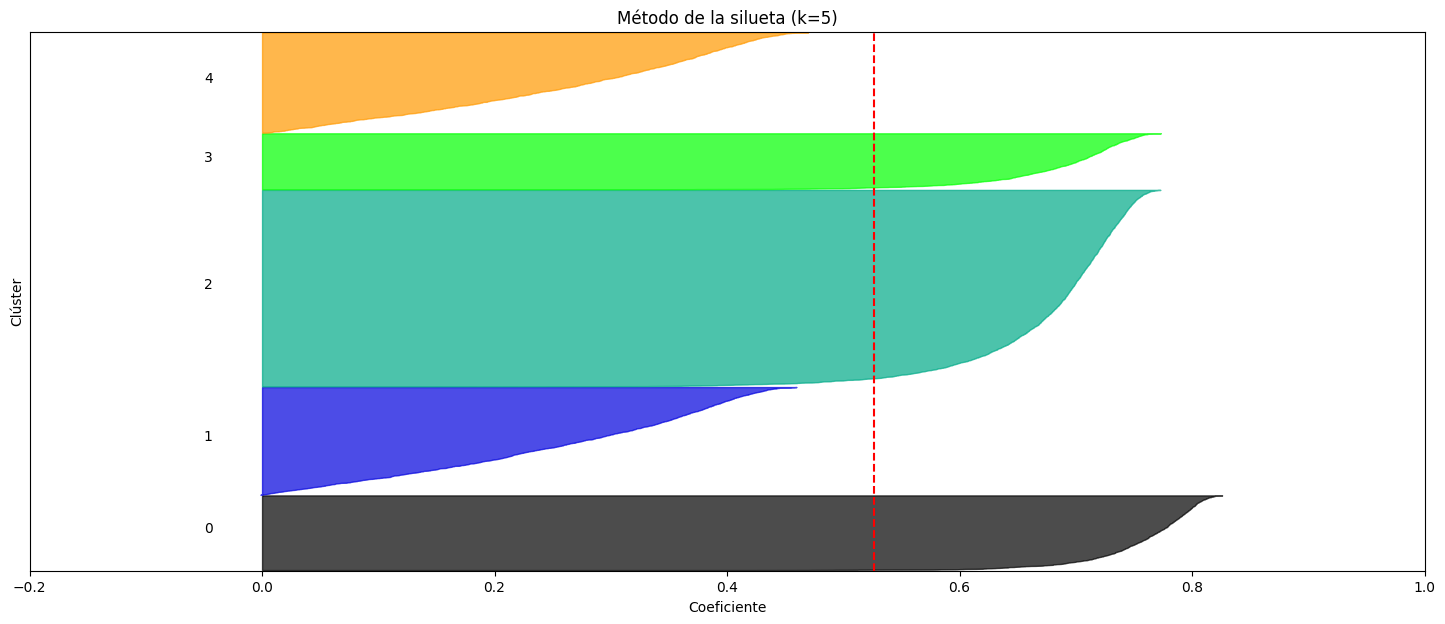

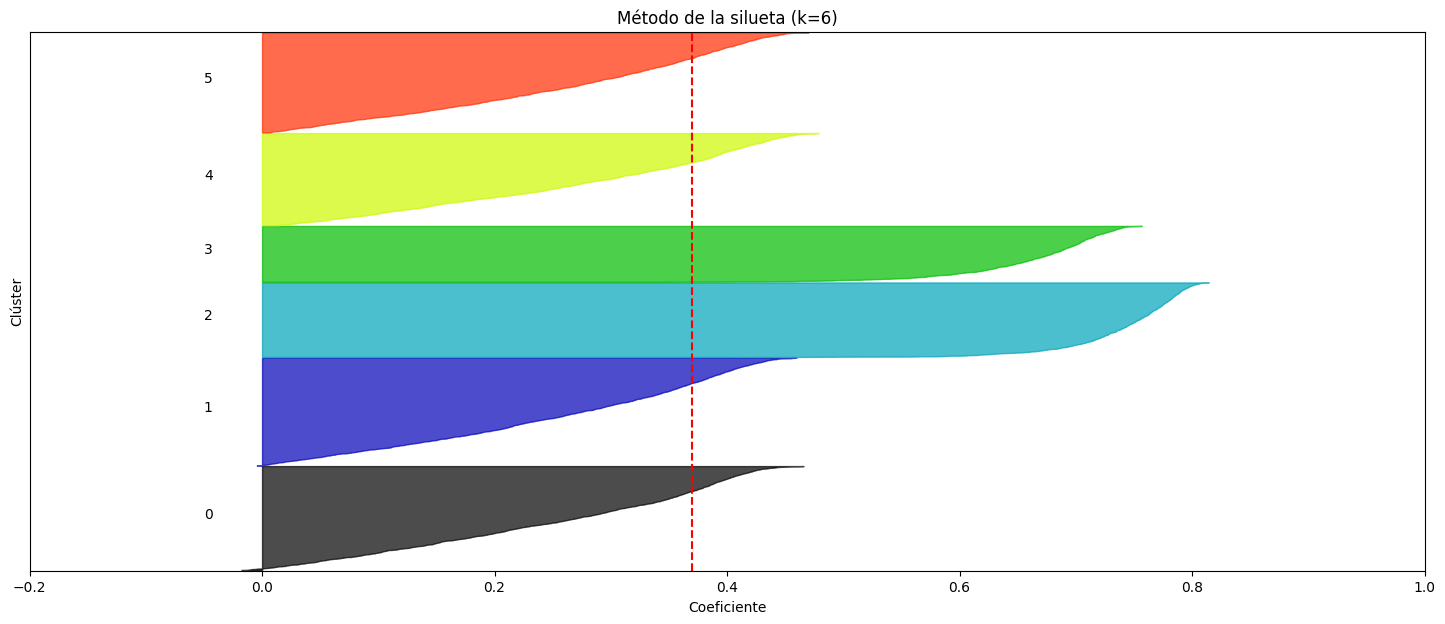

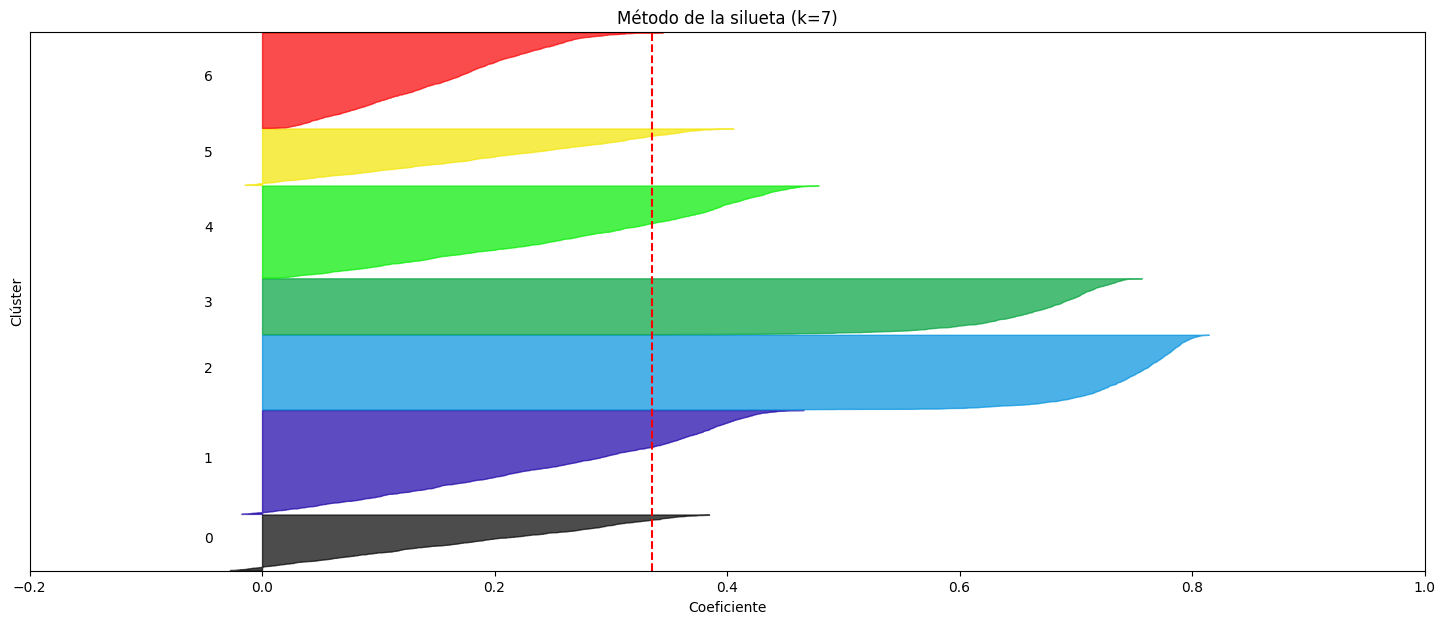

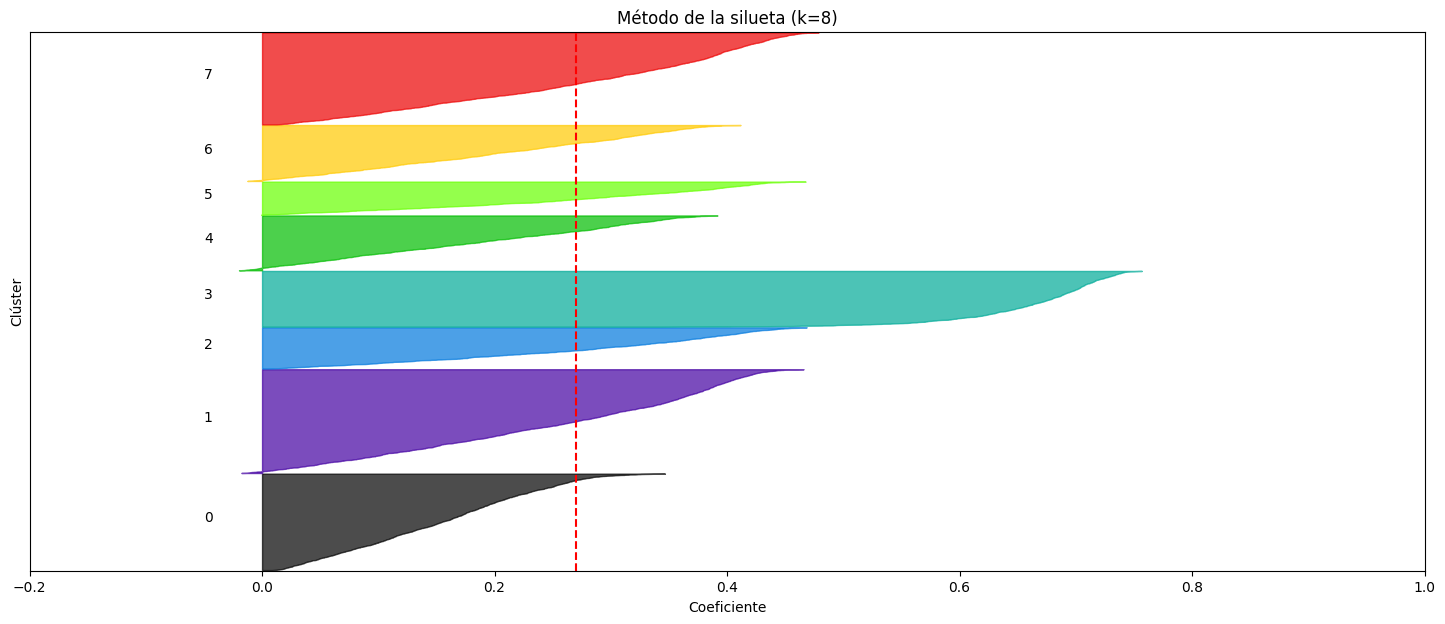

In [85]:
silhouette_analysis(data, 2, 8)

In [86]:
def pairplot_clusters(X, n_clusters=4, feature_names=None, cols=None):
    """
    Genera un pairplot coloreado por clusters usando KMeans

    Parámetros:
    X : np.array o DataFrame
        Datos de entrada
    n_clusters : int
        Número de clusters
    feature_names : list
        Nombres de columnas (si X es numpy array)
    cols : list
        Subconjunto de columnas a graficar (opcional)
    """
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    # Escalar datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Convertir a DataFrame
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(X, columns=feature_names)

    # Agregar clusters
    df["cluster"] = labels

    # Selección de columnas
    if cols is not None:
        df_plot = df[cols + ["cluster"]]
    else:
        df_plot = df

    # Pairplot
    sns.pairplot(df_plot, hue="cluster", palette="tab10")
    plt.show()

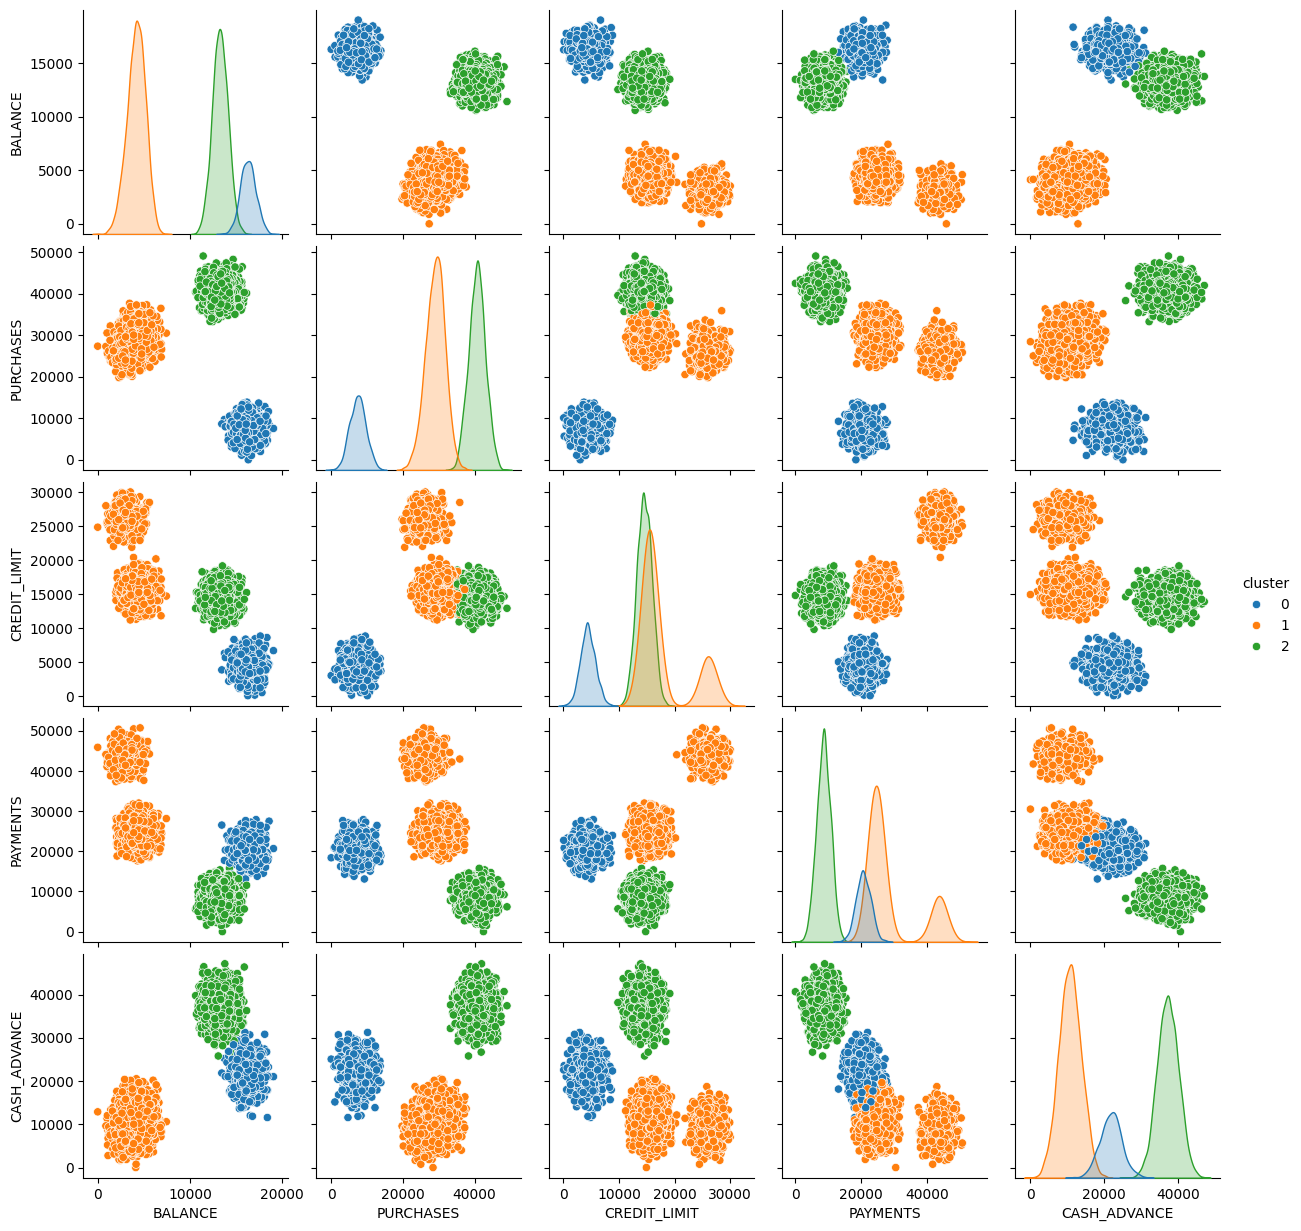

In [95]:
cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 'CASH_ADVANCE']
data_f = data[cols]
pairplot_clusters(data_f, n_clusters=3)

## 5. Análisis de resultados de agrupación.

Tras analizar ambos algoritmos, se determinó que `K=4` es el número óptimo de clústeres para particionar el espacio de datos. Por lo tanto, este valor será el utilizado para la segmentación final. 

In [ ]:
mejor_modelo = KMeans(n_clusters=4, random_state=0)
mejor_modelo.fit(scaled_df)

KMeans(n_clusters=4, random_state=0)

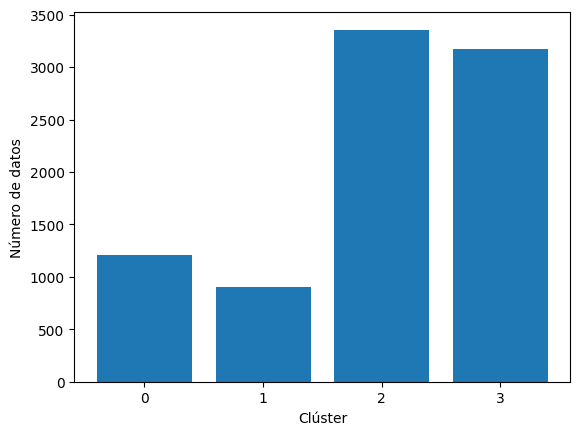

In [ ]:
labels = mejor_modelo.labels_
indexes, values = np.unique(labels, return_counts=True)
rects = plt.bar(indexes, values)
plt.xlabel('Clúster')
plt.ylabel('Número de datos')
plt.xticks(indexes)
plt.show()

Tenemos dos clústeres con más de 3000 datos, mientras que el clúster más pequeño solo tiene aproximadamente 900 clientes. Específicamente, podemos tener el número exacto de clientes en cada clúster accediendo a `indexes` y `values`:

In [ ]:
tabla = pd.DataFrame({
    'Cluster': indexes,
    'Número de clientes': values
})
tabla = tabla.sort_values(by='Cluster').reset_index(drop=True)
tabla

,Cluster,Número de clientes
0,0,1206
1,1,903
2,2,3356
3,3,3171


Para darnos una idea de cómo es cada cliente, vamos a obtener los centroides de cada grupo. En este punto haremos uso del objeto `robust_scaler` que cargamos inicialmente:

In [ ]:
centroids_array = mejor_modelo.cluster_centers_
centroids_original = robust_scaler.inverse_transform(centroids_array)
centroids = pd.DataFrame(centroids_original, columns=data.columns)
centroids

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,16285.111896,0.181718,7392.765979,31408.672313,10932.107057,21763.987743,0.513926,0.702533,0.642639,0.490455,52.631841,166.533167,4386.390604,20649.435423,55187.141515,0.149516,7.826700
1,3105.917172,0.583910,26323.521692,31054.681489,10485.803990,9355.103901,0.206352,0.797868,0.178405,0.814128,29.837209,284.805094,26109.000090,43726.525314,17429.339551,0.723273,10.598007
2,13252.473365,0.775734,40656.032468,6132.662569,19462.256862,37231.770958,0.797725,0.227979,0.534946,0.490844,92.581049,206.825089,14534.185216,8548.249145,58146.385395,0.363650,9.859058
3,4451.126307,0.193317,29747.057865,35140.273594,3313.474410,11129.239338,0.425684,0.567289,0.838328,0.201070,80.939451,85.725008,15523.980921,24623.728686,32951.234081,0.837494,6.363923


El grupo 2 se diferencia principalmente porque combina un uso extremadamente alto de cash advance (tanto en monto como en número de transacciones, siendo el más alto entre todos los grupos) con un patrón de consumo donde, aunque tiene el mayor nivel de compras totales, estas no se hacen en una sola transacción sino principalmente en cuotas (installments). En conjunto, esto lo caracteriza como un grupo de clientes muy activos que gastan mucho, dependen bastante de adelantos de efectivo y prefieren financiar sus compras en lugar de pagarlas de contado.

Podemos interpretar los centroides de la siguiente forma:

- **Clúster 0 (1206 clientes):** este segmento de clientes se caracteriza por tener el balance más alto, aunque con la frecuencia de actualización más baja. El límite de crédito es el más bajo entre los segmentos, con una cantidad de pagos media y un porcentaje bajo de pago total de su tarjeta.

- **Clúster 1 (903 clientes):** este segmento presenta el balance más bajo, así como la menor cantidad de compras. Tienen la menor cantidad de avances de efectivo (variable `CASH_ADVANCE`), con una frecuencia alta de pagos de los avances que solicitan (variable `CASH_ADVANCE_FREQUENCY`). También son los clientes que realizan compras en un solo pago con mayor frecuencia (variable `ONEOFF_PURCHASES_FREQUENCY`) y tienen un alto porcentaje de pago de su tarjeta.

- **Clúster 2 (3356 clientes):** este segmento se caracteriza por tener el segundo balance más alto, con una frecuencia de actualización del balance muy alta. Este grupo se caracteriza por realizar muchas compras (variable `PURCHASES`) y con mucha frecuencia (variable `PURCHASES_FREQUENCY`), aunque se caracterizan por realizar pagos a cuotas con media frecuencia (variable `PURCHASES_INSTALLMENTS_FREQUENCY`). Además, este segmento tiene un porcentaje de pago de su tarjeta bajo (variable `PRC_FULL_PAYMENT`).

- **Clúster 3 (3171 clientes):** este segmento de clientes presenta un balance bajo, así como una frecuencia de actualización del balance baja, aunque realizan una cantidad moderada de compras con frecuencia media. La principal característica de estos clientes es que tienen una baja cantidad de compras a cuotas, además de un porcentaje alto del pago de sus tarjetas.

## 6. Ejercicios

* **Ejercicio 1.** En el método del codo, la inercia continúa disminuyendo incluso después de superar el punto de inflexión de la gráfica. ¿Bajo qué condiciones alcanzaría esta métrica un valor de cero? ¿Sería ideal llegar a ese estado en términos de modelado? Describa la naturaleza de los clústeres en dicho escenario.

* **Ejercicio 2.** Con el objetivo de evaluar la robustez de estos modelos ante el ruido, tome el conjunto de datos original y añada a cada valor un ruido basado en una distribución normal con media 0. Incremente gradualmente la desviación estándar hasta que los resultados de los métodos del codo y de la silueta comiencen a variar. ¿Cuál de los dos algoritmos se ve afectado primero? ¿Qué conclusiones puede extraer sobre la sensibilidad de dicho algoritmo frente a datos ruidosos?

* **Ejercicio 3.** Aunque K-Means es uno de los algoritmos de agrupamiento más utilizados, su eficacia depende de la naturaleza de los datos. Investigue las suposiciones teóricas que este modelo asume sobre la distribución de los clústeres y presente un ejemplo de un conjunto de datos donde la morfología de estos impida que el algoritmo realice una partición adecuada.

* **Ejercicio 4.** Ya se ha realizado una interpretación inicial de los clústeres a partir de los prototipos obtenidos con K-Means. Sin embargo, es importante complementar este análisis mediante técnicas descriptivas que permitan validar y profundizar en las diferencias entre grupos. Para ello, realice un análisis por clúster calculando estadísticas descriptivas y construyendo diagramas de caja de cada variable segmentados por grupo. Con base en estos resultados, evalúe si las características identificadas en los prototipos se mantienen, determine qué variables discriminan mejor los clústeres y ajuste o refine la interpretación de cada grupo de manera justificada.
